In [12]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Period

In [2]:
iyear = 1960
fyear = 2025
models = ['CHIRPS','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']
variables = ['tcwv', 'ivt']

# TP & TCWV & IVT timeseries DOMAINS

## DJFM

In [4]:
tp_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    for domain in domains:
        if model=='ERA5':
            tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_DJFM_{domain}_{iyear}-{fyear}_{model}.csv')
        else:
            tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_DJFM_{domain}_1981-2024_{model}.csv')

In [5]:
var_dict = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for var in variables:
    var_dict[var] = {}
    for domain in domains:
        var_dict[var][domain] = pd.read_csv(path + f'timeseries_{var}_DJFM_{domain}_{iyear}-{fyear}_ERA5.csv')

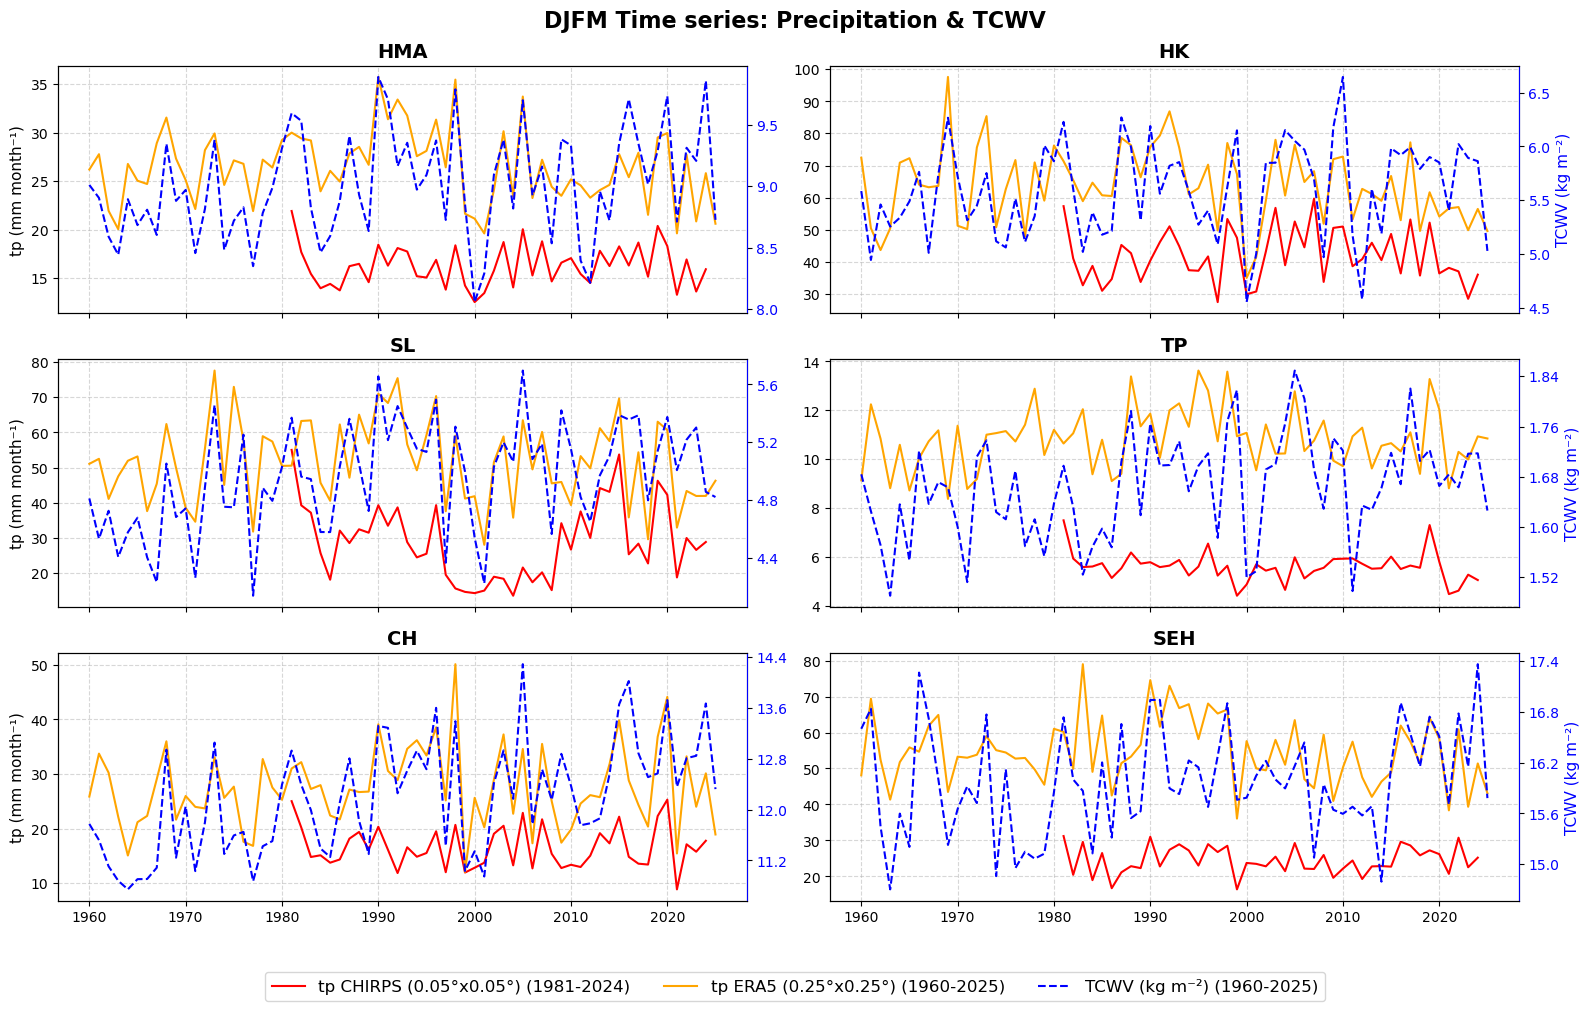

In [14]:
resolutions = {'CHIRPS': '0.05°x0.05°',
               'ERA5': '0.25°x0.25°'}

period = {'CHIRPS': '1981-2024',
          'ERA5': '1960-2025'}

colors = {'CHIRPS': 'red',
          'ERA5': 'orange'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

# pour stocker les lignes pour la légende
lines = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()  # axe droit

    # ====== PRECIP (axe gauche) ======
    for model in ['CHIRPS', 'ERA5']:
        da = tp_datasets[model][dom]

        l, = ax.plot(
            da['year'],
            da['tp'],
            linestyle='-',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=1.5
        )
        if i == 0:  # éviter duplicats dans légende
            lines.append(l)

    # ====== TCWV (axe droit) ======
    da_tcwv = var_dict['tcwv'][dom]

    l2, = ax2.plot(
        da_tcwv['year'],
        da_tcwv['tcwv'],
        color='blue',
        linestyle='--',
        linewidth=1.5,
        label=f'TCWV (kg m⁻²) ({period[model]})'
    )
    if i == 0:
        lines.append(l2)

    # ====== TITRE ======
    ax.set_title(dom, fontsize=14, weight="bold")

    # ====== LABELS ======
    # gauche (tp)
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=11)

    # droite (tcwv) seulement colonne droite
    if i in [1, 3, 5]:
        ax2.set_ylabel('TCWV (kg m⁻²)', fontsize=11, color='blue')

    # ====== STYLE AXE DROIT ======
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.yaxis.set_major_locator(MaxNLocator(5))  # ticks propres
    ax2.spines['right'].set_color('blue')

    # ====== X AXIS ======
    if i in [4, 5]:
        ax.tick_params(labelbottom=True)
    else:
        ax.tick_params(labelbottom=False)

    # ====== GRID ======
    ax.grid(True, linestyle='--', alpha=0.5)

# ====== LEGEND ======
fig.legend(
    lines,
    [l.get_label() for l in lines],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=12,
    frameon=True
)

# ====== TITRE GLOBAL ======
fig.suptitle('DJFM Time series: Precipitation & TCWV', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()